<a href="https://colab.research.google.com/github/davesagit123/blank-app/blob/main/Sectional_Z_Score_%26_Hybrid_Ranking_Tool_(.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimental Horse Hybrid Rating & Fuzzy 33% Shortlist

This notebook calculates a **field-relative hybrid rating** using:

1. Overall runner-time z-score as the primary/base metric.
2. Direction-adjusted early-pace and sectional z-scores.
3. Average z-scores for consecutive sectional pairs.
4. Normalised sectional weights.
5. A configurable sectional multiplier.
6. A strict lower-third shortlist, plus a one-horse **fuzzy extension**.

## Direction convention

Every calculated score uses **lower = better**:

- Lower overall time/sectional figures are better.
- Higher early pace is better, so its z-score is sign-reversed.

## Fuzzy shortlist rule

For a field of size $N$:

$$\text{Core slots}=\max(1,\lfloor N/3\rfloor)$$

A horse enters the **core shortlist** when its hybrid score is negative and its rank is within the core slots.
The **next-ranked horse only** is also included when its hybrid score is negative.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.options.display.float_format = "{:.3f}".format

In [10]:
# Original relative weights; automatically normalised below.
RAW_WEIGHTS = {
    "early_800": 15,
    "800_600": 15,
    "600_400": 25,
    "400": 35,
    "200": 25,
}

# 1.0 = add the complete sectional score to overall-time z-score.
SECTIONAL_MULTIPLIER = 1.0

# Population SD (ddof=0) treats the listed runners as the complete race field.
Z_DDOF = 0

weights = pd.Series(RAW_WEIGHTS, dtype=float)
weights = weights / weights.sum()
print("Normalised weights:")
display((weights * 100).rename("Weight %").to_frame())
print(f"Total: {weights.sum() * 100:.2f}%")

Normalised weights:


,Weight %
early_800,13.043
800_600,13.043
600_400,21.739
400,30.435
200,21.739


Total: 100.00%


In [11]:
import io

# Paste your data below (tab-separated including headers)
raw_data_input = """tab number	Horse Name	runner time	early pace	800	600	400	200
1	Middle Earth	-5.39L	42	-2.05L	-1.84L	-1.36L	-0.58L
2	Attrition	-3.89L	41	-2.01L	-1.47L	-0.78L	-0.20L
3	Kingswood	-11.37L	58	-2.62L	-2.08L	-1.38L	-0.46L
4	Knight's Choice	-2.99L	38	-3.43L	-2.50L	-0.99L	-0.47L
5	Royal Supremacy	-10.05L	60	-2.57L	-1.98L	-0.78L	-0.36L
6	Wootton Verni	-12.80L	65	-2.15L	-1.40L	-0.73L	+0.00L
7	Barnavara	-17.26L	76	-3.38L	-2.50L	-1.07L	-0.22L
8	Soulcombe	-26.18L	89	-2.13L	-1.37L	-1.07L	-0.42L
9	Just Folk	-10.34L	62	-2.24L	-1.80L	-0.92L	-0.12L
10	Yellow Jersey	-19.61L	57	-4.32L	-3.84L	-2.36L	-0.91L
11	Okita Soushi	-6.24L	39	-1.56L	-1.19L	-0.74L	-0.16L
12	River Of Stars	-12.45L	54	-3.06L	-2.18L	-1.21L	-0.43L
13	Deakin	-8.73L	59	-2.11L	-1.37L	-0.66L	+0.01L
14	Zahrann	+3.05L	9	-2.75L	-2.64L	-1.76L	-0.70L
15	Zakouma	-17.45L	70	-3.91L	-2.47L	-1.43L	-0.39L
16	First Chorus	-3.55L	28	-2.69L	-2.06L	-1.41L	-0.48L
"""

# Read the raw string, treating tabs as separators
race = pd.read_csv(io.StringIO(raw_data_input.strip()), sep="\t")

# Standardize column names for the model
race.columns = ["tab_number", "horse_name", "runner_time", "early_pace", "800", "600", "400", "200"]

display(race)

,tab_number,horse_name,runner_time,early_pace,800,600,400,200
0,1,Middle Earth,-5.39L,42,-2.05L,-1.84L,-1.36L,-0.58L
1,2,Attrition,-3.89L,41,-2.01L,-1.47L,-0.78L,-0.20L
2,3,Kingswood,-11.37L,58,-2.62L,-2.08L,-1.38L,-0.46L
3,4,Knight's Choice,-2.99L,38,-3.43L,-2.50L,-0.99L,-0.47L
4,5,Royal Supremacy,-10.05L,60,-2.57L,-1.98L,-0.78L,-0.36L
5,6,Wootton Verni,-12.80L,65,-2.15L,-1.40L,-0.73L,+0.00L
6,7,Barnavara,-17.26L,76,-3.38L,-2.50L,-1.07L,-0.22L
7,8,Soulcombe,-26.18L,89,-2.13L,-1.37L,-1.07L,-0.42L
8,9,Just Folk,-10.34L,62,-2.24L,-1.80L,-0.92L,-0.12L
9,10,Yellow Jersey,-19.61L,57,-4.32L,-3.84L,-2.36L,-0.91L


In [12]:
METRICS = ["runner_time", "early_pace", "800", "600", "400", "200"]

def clean_number(series):
    cleaned = (series.astype(str)
               .str.strip()
               .str.replace(",", "", regex=False)
               .str.replace(r"[Ll]$", "", regex=True)
               .str.replace("+", "", regex=False)
               .str.strip())
    return pd.to_numeric(cleaned, errors="coerce")

for column in METRICS:
    race[column] = clean_number(race[column])

# Standard z-scores
z = (race[METRICS] - race[METRICS].mean()) / race[METRICS].std(ddof=Z_DDOF)
z["early_pace"] = -z["early_pace"]

calc = race[["tab_number", "horse_name"]].copy()
calc["overall_z"] = z["runner_time"]
calc["sectional_score"] = (
    weights["early_800"] * (z["early_pace"] + z["800"]) / 2
    + weights["800_600"] * (z["800"] + z["600"]) / 2
    + weights["600_400"] * (z["600"] + z["400"]) / 2
    + weights["400"] * z["400"]
    + weights["200"] * z["200"]
)

calc["hybrid_score"] = calc["overall_z"] + SECTIONAL_MULTIPLIER * calc["sectional_score"]
calc = calc.sort_values("hybrid_score").reset_index(drop=True)
calc["hybrid_rank"] = np.arange(1, len(calc) + 1)

display(calc.round(3))

,tab_number,horse_name,overall_z,sectional_score,hybrid_score,hybrid_rank
0,10,Yellow Jersey,-1.303,-2.413,-3.716,1
1,8,Soulcombe,-2.225,0.199,-2.026,2
2,15,Zakouma,-1.000,-0.662,-1.662,3
3,7,Barnavara,-0.973,-0.101,-1.074,4
4,12,River Of Stars,-0.298,-0.205,-0.503,5
5,3,Kingswood,-0.146,-0.302,-0.449,6
6,5,Royal Supremacy,0.039,0.387,0.426,7
7,1,Middle Earth,0.693,-0.171,0.522,8
8,9,Just Folk,-0.002,0.571,0.570,9
9,6,Wootton Verni,-0.347,0.974,0.627,10


In [13]:
field_size = len(calc)
core_slots = max(1, field_size // 3)
fuzzy_candidate_rank = core_slots + 1

calc["shortlist_status"] = "Not shortlisted"
core_mask = (calc["hybrid_rank"] <= core_slots) & (calc["hybrid_score"] < 0)
fuzzy_mask = (calc["hybrid_rank"] == fuzzy_candidate_rank) & (calc["hybrid_score"] < 0)

calc.loc[core_mask, "shortlist_status"] = "CORE"
calc.loc[fuzzy_mask, "shortlist_status"] = "FUZZY +1"
calc["shortlisted"] = calc["shortlist_status"].isin(["CORE", "FUZZY +1"])

display(calc[calc["shortlisted"]].round(3))

,tab_number,horse_name,overall_z,sectional_score,hybrid_score,hybrid_rank,shortlist_status,shortlisted
0,10,Yellow Jersey,-1.303,-2.413,-3.716,1,CORE,True
1,8,Soulcombe,-2.225,0.199,-2.026,2,CORE,True
2,15,Zakouma,-1.000,-0.662,-1.662,3,CORE,True
3,7,Barnavara,-0.973,-0.101,-1.074,4,CORE,True
4,12,River Of Stars,-0.298,-0.205,-0.503,5,CORE,True
5,3,Kingswood,-0.146,-0.302,-0.449,6,FUZZY +1,True


## 6. Ranking chart

Green bars are shortlisted. Grey bars are not. Scores farther left are better.

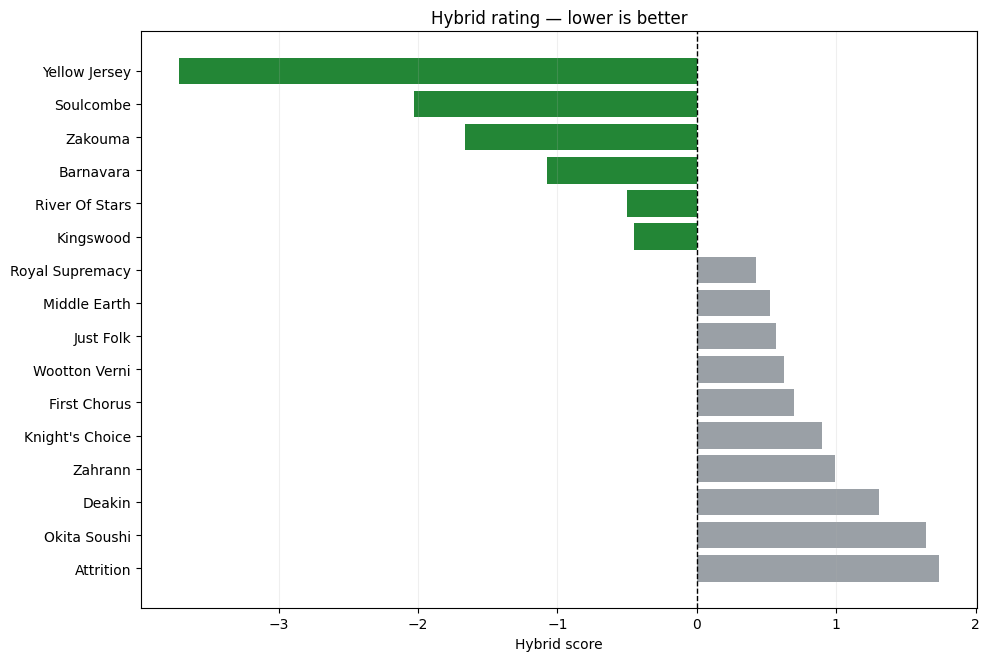

In [14]:
plot_data = calc.sort_values("hybrid_score", ascending=True).copy()
colors = np.where(plot_data["shortlisted"], "#238636", "#9aa0a6")

fig_height = max(5, 0.42 * len(plot_data))
fig, ax = plt.subplots(figsize=(10, fig_height))
ax.barh(plot_data["horse_name"], plot_data["hybrid_score"], color=colors)
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.invert_yaxis()
ax.set_title("Hybrid rating \u2014 lower is better")
ax.set_xlabel("Hybrid score")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

## 7. Export the full results and shortlist

In [15]:
full_output = calc[[
    "hybrid_rank", "tab_number", "horse_name", "overall_z",
    "sectional_score", "hybrid_score", "shortlist_status", "shortlisted"
]].copy()

full_output.to_csv("hybrid_rating_full_results.csv", index=False)
calc[calc["shortlisted"]].to_csv("hybrid_rating_shortlist.csv", index=False)

print("Saved:")
print("- hybrid_rating_full_results.csv")
print("- hybrid_rating_shortlist.csv")

Saved:
- hybrid_rating_full_results.csv
- hybrid_rating_shortlist.csv


In [16]:
{
 "cells": [
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "# Experimental Horse Hybrid Rating & Fuzzy 33% Shortlist\n",
    "\n",
    "This notebook calculates a **field-relative hybrid rating** using:\n",
    "\n",
    "1. Overall runner-time z-score as the primary/base metric.\n",
    "2. Direction-adjusted early-pace and sectional z-scores.\n",
    "3. Average z-scores for consecutive sectional pairs.\n",
    "4. Normalised sectional weights.\n",
    "5. A configurable sectional multiplier.\n",
    "6. A strict lower-third shortlist, plus a one-horse **fuzzy extension**.\n",
    "\n",
    "## Direction convention\n",
    "\n",
    "Every calculated score uses **lower = better**:\n",
    "\n",
    "- Lower overall time/sectional figures are better.\n",
    "- Higher early pace is better, so its z-score is sign-reversed.\n",
    "\n",
    "## Fuzzy shortlist rule\n",
    "\n",
    "For a field of size $N$:\n",
    "\n",
    "$$\\text{Core slots}=\\max(1,\\lfloor N/3\\rfloor)$$\n",
    "\n",
    "A horse enters the **core shortlist** when its hybrid score is negative and its rank is within the core slots.\n",
    "The **next-ranked horse only** is also included when its hybrid score is negative.\n",
    "\n",
    "Examples:\n",
    "\n",
    "- 11 runners: 3 core slots; rank 4 is included if negative.\n",
    "- 16 runners: 5 core slots; rank 6 is included if negative.\n",
    "- The extension adds no more than one horse.\n",
    "\n",
    "> Experimental model: validate it against historical out-of-sample results before using it for wagering decisions."
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "import numpy as np\n",
    "import pandas as pd\n",
    "import matplotlib.pyplot as plt\n",
    "from IPython.display import display\n",
    "\n",
    "pd.set_option(\"display.max_columns\", None)\n",
    "pd.set_option(\"display.width\", 160)\n",
    "pd.options.display.float_format = \"{:.3f}\".format"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## 1. Model settings\n",
    "\n",
    "The raw weights are automatically normalised, so they do not need to total 100.\n",
    "\n",
    "`SECTIONAL_MULTIPLIER = 1.0` reproduces the full-addition method:\n",
    "\n",
    "$$\text{Hybrid}=z_{overall}+\text{Sectional score}$$\n",
    "\n",
    "If you later want overall time to exert more influence, try `0.50` and compare historical results."
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "# Original relative weights; automatically normalised below.\n",
    "RAW_WEIGHTS = {\n",
    "    \"early_800\": 15,\n",
    "    \"800_600\": 15,\n",
    "    \"600_400\": 25,\n",
    "    \"400\": 35,\n",
    "    \"200\": 25,\n",
    "}\n",
    "\n",
    "# 1.0 = add the complete sectional score to overall-time z-score.\n",
    "SECTIONAL_MULTIPLIER = 1.0\n",
    "\n",
    "# Population SD (ddof=0) treats the listed runners as the complete race field.\n",
    "Z_DDOF = 0\n",
    "\n",
    "weights = pd.Series(RAW_WEIGHTS, dtype=float)\n",
    "weights = weights / weights.sum()\n",
    "print(\"Normalised weights:\")\n",
    "display((weights * 100).rename(\"Weight %\").to_frame())\n",
    "print(f\"Total: {weights.sum() * 100:.2f}%\")"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## 2. Enter race data\n",
    "\n",
    "Replace the sample rows below for a new race. Values may be entered as numbers or as strings such as `-5.39L`, `+0.00L`, or `42`.\n",
    "\n",
    "Required columns:\n",
    "\n",
    "- `tab_number`\n",
    "- `horse_name`\n",
    "- `runner_time`\n",
    "- `early_pace`\n",
    "- `800`, `600`, `400`, `200`"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "data = [\n",
    "    [1,  \"Middle Earth\",      \"-5.39L\", 42, \"-2.05L\", \"-1.84L\", \"-1.36L\", \"-0.58L\"],\n",
    "    [2,  \"Attrition\",         \"-3.89L\", 41, \"-2.01L\", \"-1.47L\", \"-0.78L\", \"-0.20L\"],\n",
    "    [3,  \"Kingswood\",        \"-11.37L\", 58, \"-2.62L\", \"-2.08L\", \"-1.38L\", \"-0.46L\"],\n",
    "    [4,  \"Knight's Choice\",  \"-2.99L\", 38, \"-3.43L\", \"-2.50L\", \"-0.99L\", \"-0.47L\"],\n",
    "    [5,  \"Royal Supremacy\", \"-10.05L\", 60, \"-2.57L\", \"-1.98L\", \"-0.78L\", \"-0.36L\"],\n",
    "    [6,  \"Wootton Verni\",   \"-12.80L\", 65, \"-2.15L\", \"-1.40L\", \"-0.73L\", \"+0.00L\"],\n",
    "    [7,  \"Barnavara\",       \"-17.26L\", 76, \"-3.38L\", \"-2.50L\", \"-1.07L\", \"-0.22L\"],\n",
    "    [8,  \"Soulcombe\",       \"-26.18L\", 89, \"-2.13L\", \"-1.37L\", \"-1.07L\", \"-0.42L\"],\n",
    "    [9,  \"Just Folk\",       \"-10.34L\", 62, \"-2.24L\", \"-1.80L\", \"-0.92L\", \"-0.12L\"],\n",
    "    [10, \"Yellow Jersey\",   \"-19.61L\", 57, \"-4.32L\", \"-3.84L\", \"-2.36L\", \"-0.91L\"],\n",
    "    [11, \"Okita Soushi\",     \"-6.24L\", 39, \"-1.56L\", \"-1.19L\", \"-0.74L\", \"-0.16L\"],\n",
    "    [12, \"River Of Stars\",  \"-12.45L\", 54, \"-3.06L\", \"-2.18L\", \"-1.21L\", \"-0.43L\"],\n",
    "    [13, \"Deakin\",           \"-8.73L\", 59, \"-2.11L\", \"-1.37L\", \"-0.66L\", \"+0.01L\"],\n",
    "    [14, \"Zahrann\",          \"+3.05L\",  9, \"-2.75L\", \"-2.64L\", \"-1.76L\", \"-0.70L\"],\n",
    "    [15, \"Zakouma\",         \"-17.45L\", 70, \"-3.91L\", \"-2.47L\", \"-1.43L\", \"-0.39L\"],\n",
    "    [16, \"First Chorus\",     \"-3.55L\", 28, \"-2.69L\", \"-2.06L\", \"-1.41L\", \"-0.48L\"],\n",
    "]\n",
    "\n",
    "columns = [\"tab_number\", \"horse_name\", \"runner_time\", \"early_pace\", \"800\", \"600\", \"400\", \"200\"]\n",
    "race = pd.DataFrame(data, columns=columns)\n",
    "display(race)"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "### Optional: upload a CSV in Google Colab\n",
    "\n",
    "Leave this cell unrun when using the data entered above. Your CSV must contain the same required column names."
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "# OPTIONAL GOOGLE COLAB CSV UPLOAD\n",
    "# Uncomment these lines to upload a CSV and replace the `race` DataFrame.\n",
    "#\n",
    "# from google.colab import files\n",
    "# uploaded = files.upload()\n",
    "# csv_name = next(iter(uploaded))\n",
    "# race = pd.read_csv(csv_name)\n",
    "# display(race.head())"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## 3. Clean and validate the inputs\n",
    "\n",
    "The cleaner removes `L`, spaces, commas, and leading plus signs. The notebook stops with a clear error if values are missing, non-numeric, duplicated, or if a metric has zero variation."
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "REQUIRED_COLUMNS = [\"tab_number\", \"horse_name\", \"runner_time\", \"early_pace\", \"800\", \"600\", \"400\", \"200\"]\n",
    "METRICS = [\"runner_time\", \"early_pace\", \"800\", \"600\", \"400\", \"200\"]\n",
    "\n",
    "missing_columns = [c for c in REQUIRED_COLUMNS if c not in race.columns]\n",
    "if missing_columns:\n",
    "    raise ValueError(f\"Missing required columns: {missing_columns}\")\n",
    "\n",
    "race = race[REQUIRED_COLUMNS].copy()\n",
    "\n",
    "def clean_number(series):\n",
    "    cleaned = (series.astype(str)\n",
    "               .str.strip()\n",
    "               .str.replace(\",\", \"\", regex=False)\n",
    "               .str.replace(r\"[Ll]$\", \"\", regex=True)\n",
    "               .str.replace(\"+\", \"\", regex=False)\n",
    "               .str.strip())\n",
    "    return pd.to_numeric(cleaned, errors=\"coerce\")\n",
    "\n",
    "for column in METRICS:\n",
    "    race[column] = clean_number(race[column])\n",
    "\n",
    "if race[REQUIRED_COLUMNS].isna().any().any():\n",
    "    bad = race[race[REQUIRED_COLUMNS].isna().any(axis=1)]\n",
    "    display(bad)\n",
    "    raise ValueError(\"Missing or non-numeric input detected in the rows displayed above.\")\n",
    "if race[\"tab_number\"].duplicated().any():\n",
    "    raise ValueError(\"Duplicate tab numbers detected.\")\n",
    "if race[\"horse_name\"].duplicated().any():\n",
    "    raise ValueError(\"Duplicate horse names detected.\")\n",
    "if len(race) < 2:\n",
    "    raise ValueError(\"At least two runners are required.\")\n",
    "if (race[METRICS].std(ddof=Z_DDOF) == 0).any():\n",
    "    flat = race[METRICS].std(ddof=Z_DDOF)\n",
    "    raise ValueError(f\"These metrics have no variation and cannot be z-scored: {flat[flat == 0].index.tolist()}\")\n",
    "\n",
    "print(f\"Validated {len(race)} runners.\")\n",
    "display(race)"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## 4. Calculate z-scores, pairs and hybrid rating\n",
    "\n",
    "The early-pace z-score is reversed because higher early pace is better. Pair scores are averages, not sums."
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "# Standard z-scores.\n",
    "z = (race[METRICS] - race[METRICS].mean()) / race[METRICS].std(ddof=Z_DDOF)\n",
    "\n",
    "# Reverse early pace so lower remains better throughout the model.\n",
    "z[\"early_pace\"] = -z[\"early_pace\"]\n",
    "\n",
    "calc = race[[\"tab_number\", \"horse_name\"]].copy()\n",
    "calc[\"overall_z\"] = z[\"runner_time\"]\n",
    "calc[\"early_z_adjusted\"] = z[\"early_pace\"]\n",
    "calc[\"z_800\"] = z[\"800\"]\n",
    "calc[\"z_600\"] = z[\"600\"]\n",
    "calc[\"z_400\"] = z[\"400\"]\n",
    "calc[\"z_200\"] = z[\"200\"]\n",
    "\n",
    "calc[\"pair_early_800\"] = (calc[\"early_z_adjusted\"] + calc[\"z_800\"]) / 2\n",
    "calc[\"pair_800_600\"] = (calc[\"z_800\"] + calc[\"z_600\"]) / 2\n",
    "calc[\"pair_600_400\"] = (calc[\"z_600\"] + calc[\"z_400\"]) / 2\n",
    "\n",
    "calc[\"sectional_score\"] = (\n",
    "    weights[\"early_800\"] * calc[\"pair_early_800\"]\n",
    "    + weights[\"800_600\"] * calc[\"pair_800_600\"]\n",
    "    + weights[\"600_400\"] * calc[\"pair_600_400\"]\n",
    "    + weights[\"400\"] * calc[\"z_400\"]\n",
    "    + weights[\"200\"] * calc[\"z_200\"]\n",
    ")\n",
    "\n",
    "calc[\"hybrid_score\"] = calc[\"overall_z\"] + SECTIONAL_MULTIPLIER * calc[\"sectional_score\"]\n",
    "\n",
    "# Stable tie handling: hybrid, overall, sectional, then tab number.\n",
    "calc = calc.sort_values(\n",
    "    [\"hybrid_score\", \"overall_z\", \"sectional_score\", \"tab_number\"],\n",
    "    ascending=[True, True, True, True]\n",
    ").reset_index(drop=True)\n",
    "calc[\"hybrid_rank\"] = np.arange(1, len(calc) + 1)\n",
    "\n",
    "print(\"Lower scores are better.\")\n",
    "display(calc.round(3))"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## 5. Apply the fuzzy 33% rule\n",
    "\n",
    "- `core_slots = floor(field size / 3)`, with a minimum of one.\n",
    "- Core runners must still have a negative hybrid score.\n",
    "- Rank `core_slots + 1` is the sole fuzzy candidate.\n",
    "- That candidate is added only if its hybrid score is negative."
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "field_size = len(calc)\n",
    "core_slots = max(1, field_size // 3)\n",
    "fuzzy_candidate_rank = core_slots + 1\n",
    "\n",
    "calc[\"shortlist_status\"] = \"Not shortlisted\"\n",
    "core_mask = (calc[\"hybrid_rank\"] <= core_slots) & (calc[\"hybrid_score\"] < 0)\n",
    "fuzzy_mask = (calc[\"hybrid_rank\"] == fuzzy_candidate_rank) & (calc[\"hybrid_score\"] < 0)\n",
    "\n",
    "calc.loc[core_mask, \"shortlist_status\"] = \"CORE\"\n",
    "calc.loc[fuzzy_mask, \"shortlist_status\"] = \"FUZZY +1\"\n",
    "calc[\"shortlisted\"] = calc[\"shortlist_status\"].isin([\"CORE\", \"FUZZY +1\"])\n",
    "\n",
    "shortlist = calc.loc[calc[\"shortlisted\"], [\n",
    "    \"hybrid_rank\", \"tab_number\", \"horse_name\", \"overall_z\",\n",
    "    \"sectional_score\", \"hybrid_score\", \"shortlist_status\"\n",
    "]].copy()\n",
    "\n",
    "print(f\"Field size: {field_size}\")\n",
    "print(f\"Strict lower-third core slots: {core_slots}\")\n",
    "print(f\"One possible fuzzy extension: rank {fuzzy_candidate_rank}, only when negative\")\n",
    "print(f\"Final shortlist size: {len(shortlist)}\")\n",
    "\n",
    "display(shortlist.round(3))"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## 6. Ranking chart\n",
    "\n",
    "Green bars are shortlisted. Grey bars are not. Scores farther left are better."
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "plot_data = calc.sort_values(\"hybrid_score\", ascending=True).copy()\n",
    "colors = np.where(plot_data[\"shortlisted\"], \"#238636\", \"#9aa0a6\")\n",
    "\n",
    "fig_height = max(5, 0.42 * len(plot_data))\n",
    "fig, ax = plt.subplots(figsize=(10, fig_height))\n",
    "ax.barh(plot_data[\"horse_name\"], plot_data[\"hybrid_score\"], color=colors)\n",
    "ax.axvline(0, color=\"black\", linewidth=1, linestyle=\"--\")\n",
    "ax.invert_yaxis()\n",
    "ax.set_title(\"Hybrid rating \u2014 lower is better\")\n",
    "ax.set_xlabel(\"Hybrid score\")\n",
    "ax.grid(axis=\"x\", alpha=0.2)\n",
    "plt.tight_layout()\n",
    "plt.show()"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## 7. Export the full results and shortlist\n",
    "\n",
    "In Colab, uncomment the download lines if you want the browser to download both CSV files immediately."
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "full_output = calc[[\n",
    "    \"hybrid_rank\", \"tab_number\", \"horse_name\", \"overall_z\",\n",
    "    \"sectional_score\", \"hybrid_score\", \"shortlist_status\", \"shortlisted\"\n",
    "]].copy()\n",
    "\n",
    "full_output.to_csv(\"hybrid_rating_full_results.csv\", index=False)\n",
    "shortlist.to_csv(\"hybrid_rating_shortlist.csv\", index=False)\n",
    "\n",
    "print(\"Saved:\")\n",
    "print(\"- hybrid_rating_full_results.csv\")\n",
    "print(\"- hybrid_rating_shortlist.csv\")\n",
    "\n",
    "# OPTIONAL COLAB DOWNLOADS\n",
    "# from google.colab import files\n",
    "# files.download(\"hybrid_rating_full_results.csv\")\n",
    "# files.download(\"hybrid_rating_shortlist.csv\")"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## Sample-data expectation\n",
    "\n",
    "With `SECTIONAL_MULTIPLIER = 1.0`, this 16-runner sample has five strict core slots. **Kingswood**, ranked sixth with a negative hybrid score, is admitted as the single **FUZZY +1** runner.\n",
    "\n",
    "### Testing ideas\n",
    "\n",
    "For historical validation, record at least:\n",
    "\n",
    "- wins and places by `CORE` versus `FUZZY +1`;\n",
    "- strike rate and return on investment;\n",
    "- performance by field size and race type;\n",
    "- results using sectional multipliers such as `0.50`, `0.75`, and `1.00`;\n",
    "- whether the extra fuzzy runner improves coverage enough to justify the additional selection.\n",
    "\n",
    "Do not tune and assess the model on the same races. Set aside later races as an untouched test sample."
   ]
  }
 ],
 "metadata": {
  "colab": {
   "name": "Experimental_Horse_Hybrid_Rating.ipynb",
   "provenance": []
  },
  "kernelspec": {
   "display_name": "Python 3",
   "language": "python",
   "name": "python3"
  },
  "language_info": {
   "name": "python",
   "version": "3.x"
  }
 },
 "nbformat": 4,
 "nbformat_minor": 5
}

NameError: name 'null' is not defined